In [5]:
import os
env = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000")
env



'http://mlflow:5000'

In [ ]:
# Installer pandas avec les magics Jupyter si besoin
%pip install pandas
# Si tu utilises conda, tu peux aussi essayer :
# %conda install pandas

In [ ]:
# Installer pandas avec les magics Jupyter si besoin
%pip install pandas tensorflow
from tensorflow import keras

(X, y), (x_test, y_test) = keras.datasets.mnist.load_data()
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np



X_df = pd.DataFrame(X.reshape(X.shape[0], -1))
# X_df = X_df.drop_duplicates()
y_df = pd.DataFrame(y, columns=['target'])
print("Shape of X_df:", X_df.shape)
print("Shape of y_df:", y_df.shape)


Shape of X_df: (60000, 784)
Shape of y_df: (60000, 1)


In [6]:
# sauvegarde des données dans le dossier data
import os
os.makedirs("./data", exist_ok=True)
df_full = X_df.copy()
df_full['target'] = y_df['target']
df_full.to_csv("./data/mnist_full.csv", index=False)
print("Données MNIST sauvegardées dans le fichier mnist_full.csv du dossier data.")

Données MNIST sauvegardées dans le fichier mnist_full.csv du dossier data.


In [5]:
import pandas as pd
import sys

# Charger le fichier CSV
file_path = "./data/mnist_full.csv"
df = pd.read_csv(file_path)

def showimg(df, index):
    if index < 0 or index >= len(df):
        print(f"Index {index} hors limites (0-{len(df)-1})")
        sys.exit(1)

    row = df.iloc[index]
    X = row.drop('target').values.reshape(28, 28)
    y = row['target']

    print(f"Label (target) : {y}")

    try:
        import matplotlib.pyplot as plt
        plt.imshow(X, cmap='gray')
        plt.title(f"Index {index} - Label: {y}")
        plt.axis('off')
        plt.show()
    except ImportError:
        print("matplotlib n'est pas installé, affichage image impossible.")
   

Label (target) : 7


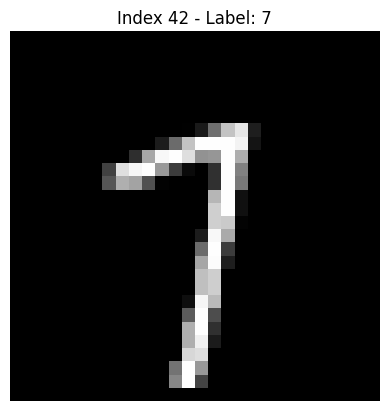

In [6]:
showimg(df, 42)

In [26]:
from models.keras_mnist_models import (
    create_nn_model,
    train_model,
    model_predict,
    model_evaluate,
    model_preprocess
)

In [ ]:
# maj des imports pour éviter les erreurs de module introuvable
import importlib
import models.keras_mnist_models
importlib.reload(models.keras_mnist_models)
from models.keras_mnist_models import model_preprocess

In [13]:
df.describe()


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0,60000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0,4.453933
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0,2.889270
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,2.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,4.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,7.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0,9.000000


In [31]:
X, y, _ = model_preprocess(df)

In [ ]:
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000348,0.000179,0.000076,0.000059,0.000008,0.0,0.0,0.0,0.0,0.017466
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.015514,0.011137,0.006615,0.006582,0.001359,0.0,0.0,0.0,0.0,0.011330
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.007843
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.015686
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.027451
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.996078,0.992157,0.992157,0.996078,0.243137,0.0,0.0,0.0,0.0,0.035294


In [32]:
import mlflow
from settings.mlflow_settings import artifact_path
run_id = "17865ca2b32c40bda882dd0956d5afb9"
model_uri = f"runs:/{run_id}/{artifact_path}"
model = mlflow.keras.load_model(model_uri)
print(model)

MlflowException: Run '17865ca2b32c40bda882dd0956d5afb9' not found